# Predictive Modeling Using Machine Learning
## Bank Marketing Campaign — Term Deposit Subscription Prediction

This notebook builds and compares three machine learning models to predict whether a bank
client will subscribe to a term deposit, based on the UCI **Bank Marketing** dataset.

**Target variable:** `y` (yes / no) → this is a **binary classification** problem.

### Table of Contents
1. [Import Libraries](#1)
2. [Load Dataset](#2)
3. [Data Preprocessing](#3)
4. [Train-Test Split](#4)
5. [Model Building & Training](#5)
6. [Model Evaluation](#6)
7. [Model Comparison](#7)
8. [Best Model Selection](#8)
9. [Conclusion](#9)
---

<a id="1"></a>
## 1. Import Libraries

We import the standard libraries required for data handling, visualization, and machine learning.

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


<a id="2"></a>
## 2. Load Dataset

We load the CSV dataset and take an initial look at its structure, data types, and summary statistics.

In [2]:
# Load the dataset
df = pd.read_csv("../data/dataset.csv")

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 41188 rows, 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
# Summary statistics for numerical columns
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Target variable distribution
print(df["y"].value_counts())
print()
print(df["y"].value_counts(normalize=True).round(3) * 100, "%")

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     88.7
yes    11.3
Name: proportion, dtype: float64 %


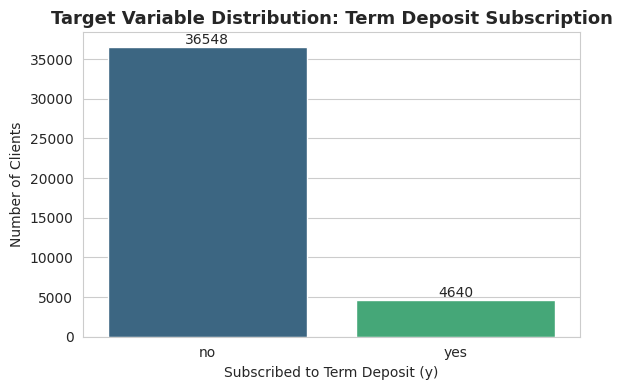

In [6]:
# Visualize target class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="y", data=df, hue="y", palette="viridis", legend=False)
plt.title("Target Variable Distribution: Term Deposit Subscription", fontsize=13, fontweight="bold")
plt.xlabel("Subscribed to Term Deposit (y)")
plt.ylabel("Number of Clients")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

<a id="3"></a>
## 3. Data Preprocessing

This section handles:
- **Missing values** — the categorical columns in this dataset use the literal string `"unknown"`
  to represent missing information. We convert these to proper `NaN` values and impute them.
- **Duplicate rows** — identified and removed.
- **Categorical encoding** — all categorical (text) columns are label-encoded so they can be
  used by the ML models.
- **Feature preparation** — separating features (`X`) from the target (`y`).

In [7]:
# Identify categorical (text) columns
categorical_cols = [
    c for c in df.columns
    if pd.api.types.is_string_dtype(df[c]) or df[c].dtype == object
]
categorical_cols.remove("y")  # target handled separately

print("Categorical columns:", categorical_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### 3.1 Handle Missing Values

The dataset does not contain traditional `NaN` values, but several categorical columns use
`"unknown"` as a placeholder for missing data. We treat these as missing values and impute
them using the **mode** (most frequent category) of each column.

In [8]:
# Replace "unknown" with NaN to properly represent missing data
df[categorical_cols] = df[categorical_cols].replace("unknown", np.nan)

missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print("Missing values per column (originally labeled 'unknown'):")
print(missing_summary)

Missing values per column (originally labeled 'unknown'):
job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64


In [9]:
# Impute missing categorical values with the column mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


### 3.2 Remove Duplicate Rows

In [10]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 14


Dataset shape after removing duplicates: (41174, 21)


### 3.3 Encode Categorical Variables

We use **Label Encoding** to convert all categorical text columns (including the target `y`)
into numeric form so the models can process them.

In [11]:
label_encoders = {}

for col in categorical_cols + ["y"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Encoding complete. Sample of encoded data:")
df.head()

Encoding complete. Sample of encoded data:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


### 3.4 Feature Selection / Preparation

We separate the dataset into the feature matrix `X` and the target vector `y`. All available
columns are used as features except the target itself.

In [12]:
X = df.drop(columns=["y"])
y = df["y"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
X.columns.tolist()

Feature matrix shape: (41174, 20)
Target vector shape:  (41174,)


['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

### 3.5 Feature Correlation Overview

A quick correlation heatmap helps visualize relationships between numerical features before modeling.

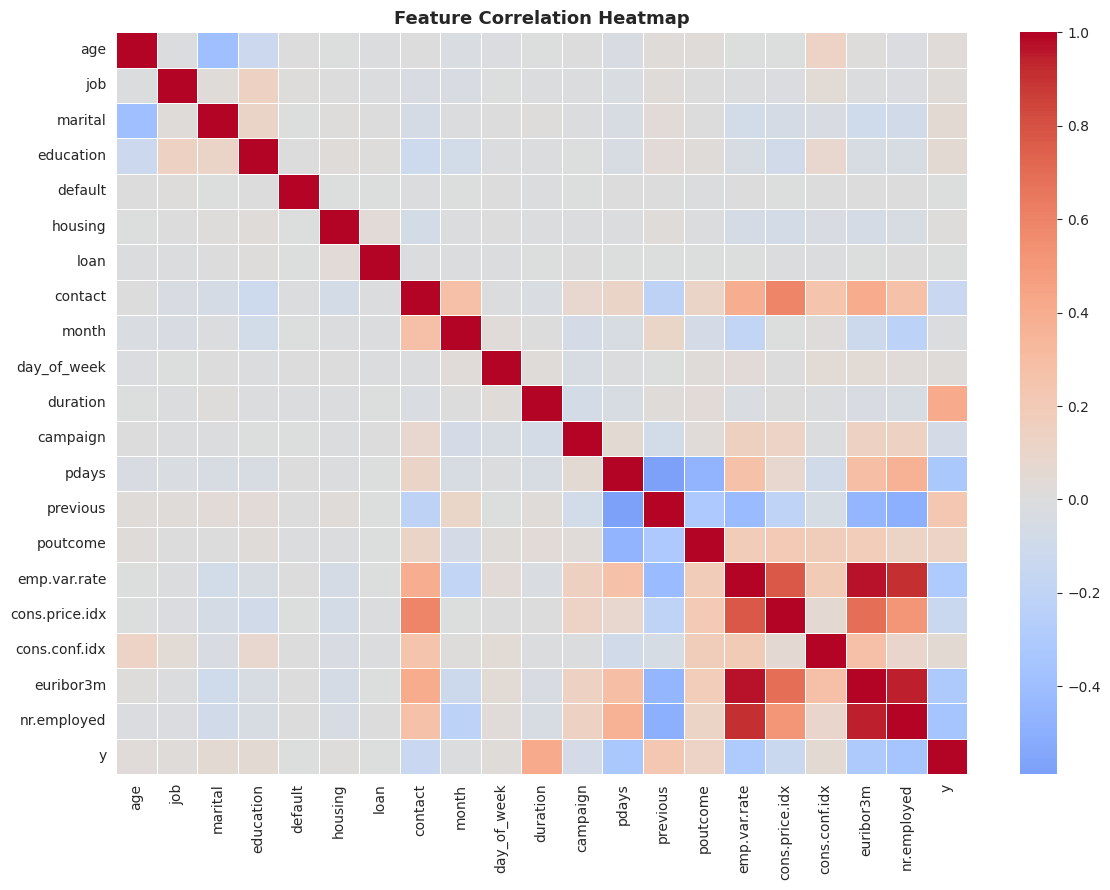

In [13]:
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

<a id="4"></a>
## 4. Train-Test Split

The dataset is split into training (80%) and testing (20%) sets. `stratify=y` is used to
preserve the class distribution in both sets, since the target classes are imbalanced.

Feature scaling (`StandardScaler`) is also applied for models that benefit from it
(Logistic Regression). Tree-based models (Decision Tree, Random Forest) do not require scaling.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 32939 samples
Testing set:  8235 samples


In [15]:
# Feature scaling (used for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<a id="5"></a>
## 5. Model Building & Training

Since the target variable is **categorical** (binary: subscribed / not subscribed), we build
three classification models:

1. **Logistic Regression** — a simple, interpretable linear baseline model.
2. **Decision Tree Classifier** — a non-linear model that captures feature interactions.
3. **Random Forest Classifier** — an ensemble of decision trees for improved accuracy and
   robustness.

Logistic Regression is trained on **scaled** features, while the tree-based models are
trained on the **original (unscaled)** features, as scaling does not affect their splits.

In [16]:
# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

# 2. Decision Tree
dec_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
dec_tree.fit(X_train, y_train)

# 3. Random Forest
rand_forest = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, max_depth=15, n_jobs=-1
)
rand_forest.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


<a id="6"></a>
## 6. Model Evaluation

Each model is evaluated on the held-out test set using:
- **Accuracy**
- **Precision, Recall, F1-score**
- **Confusion Matrix**
- **ROC Curve and AUC score**

In [17]:
def evaluate_model(name, model, X_te, y_te):
    """Compute predictions, probabilities, and standard classification metrics."""
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds),
        "Recall": recall_score(y_te, preds),
        "F1-Score": f1_score(y_te, preds),
    }
    return metrics, preds, probs


# Evaluate each model
lr_metrics, lr_preds, lr_probs = evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test)
dt_metrics, dt_preds, dt_probs = evaluate_model("Decision Tree", dec_tree, X_test, y_test)
rf_metrics, rf_preds, rf_probs = evaluate_model("Random Forest", rand_forest, X_test, y_test)

all_metrics = [lr_metrics, dt_metrics, rf_metrics]
for m in all_metrics:
    print(m)

{'Model': 'Logistic Regression', 'Accuracy': 0.9091681845780206, 'Precision': 0.6530612244897959, 'Recall': 0.41379310344827586, 'F1-Score': 0.5065963060686016}
{'Model': 'Decision Tree', 'Accuracy': 0.9092896174863389, 'Precision': 0.6170763260025873, 'Recall': 0.5140086206896551, 'F1-Score': 0.5608465608465608}
{'Model': 'Random Forest', 'Accuracy': 0.9132969034608379, 'Precision': 0.6449864498644986, 'Recall': 0.5129310344827587, 'F1-Score': 0.5714285714285714}


### 6.1 Confusion Matrices

The confusion matrix shows how many predictions were correctly/incorrectly classified for
each class (0 = No, 1 = Yes).

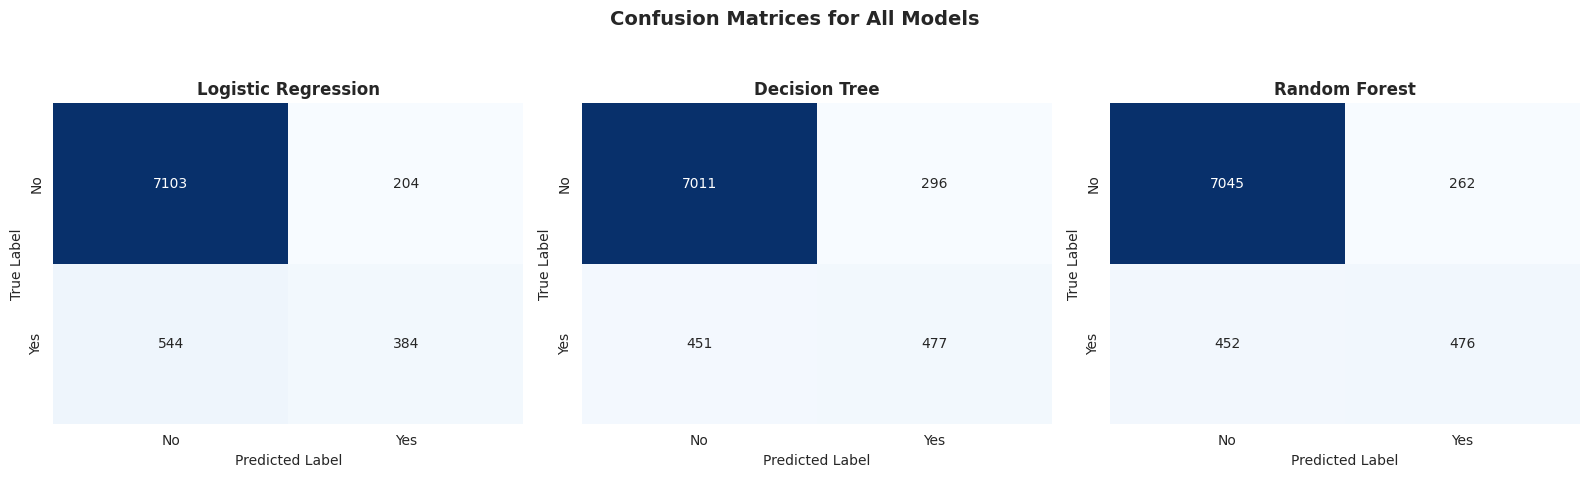

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

model_preds = {
    "Logistic Regression": lr_preds,
    "Decision Tree": dt_preds,
    "Random Forest": rf_preds,
}

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax
    )
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices for All Models", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 ROC Curves

The ROC curve plots the True Positive Rate against the False Positive Rate at various
classification thresholds. The Area Under the Curve (AUC) summarizes overall model
performance — higher is better.

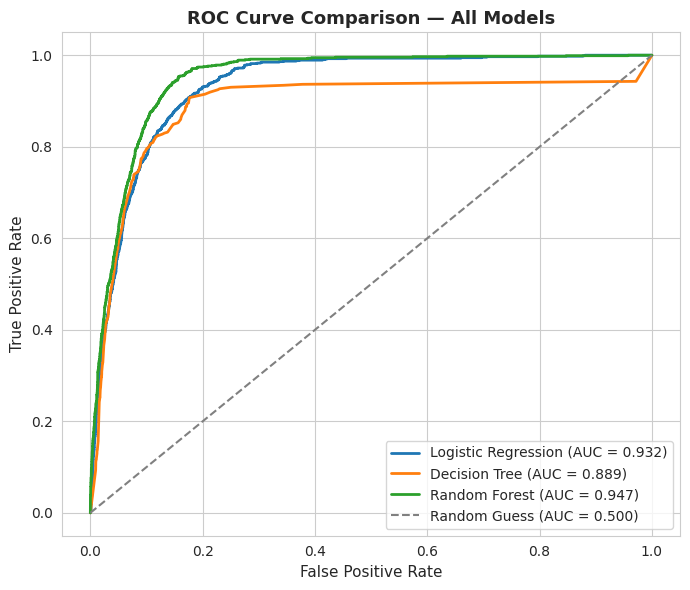

In [19]:
plt.figure(figsize=(7, 6))

model_probs = {
    "Logistic Regression": lr_probs,
    "Decision Tree": dt_probs,
    "Random Forest": rf_probs,
}

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for (name, probs), color in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess (AUC = 0.500)")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve Comparison — All Models", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Feature Importance (Random Forest)

Since Random Forest is an ensemble of decision trees, it provides a natural measure of
feature importance — how much each feature contributes to reducing prediction error.

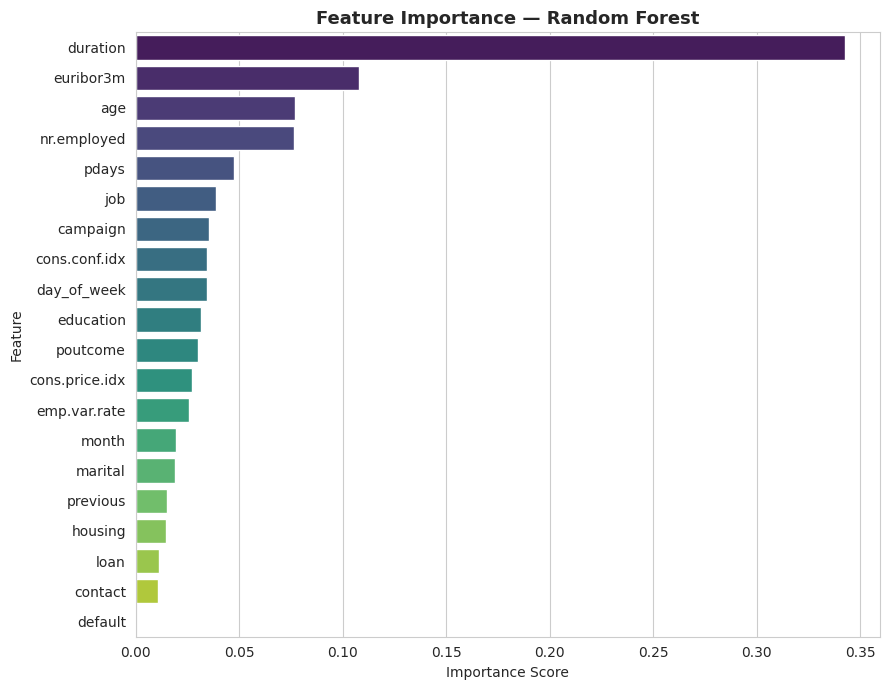

In [20]:
feature_importance = pd.Series(
    rand_forest.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index,
    hue=feature_importance.index,
    palette="viridis",
    legend=False,
)
plt.title("Feature Importance — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="7"></a>
## 7. Model Comparison

The table below summarizes the performance of all three models across every evaluation metric,
including the ROC-AUC score.

In [21]:
# Add AUC scores to the metrics
auc_scores = {}
for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_scores[name] = auc(fpr, tpr)

for m in all_metrics:
    m["ROC-AUC"] = auc_scores[m["Model"]]

comparison_df = pd.DataFrame(all_metrics).set_index("Model").round(4)
comparison_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9133,0.6450,0.5129,0.5714,0.9471
Decision Tree,0.9093,0.6171,0.5140,0.5608,0.8887
Logistic Regression,0.9092,0.6531,0.4138,0.5066,0.9318


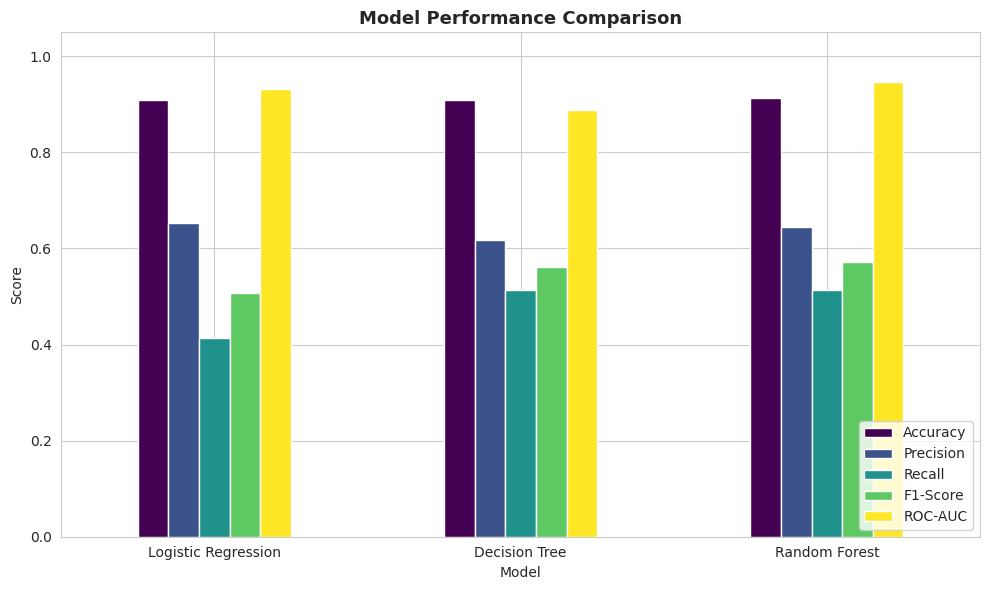

In [22]:
# Visualize the comparison
comparison_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)
plt.title("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<a id="8"></a>
## 8. Best Model Selection

In [23]:
best_model_name = comparison_df["Accuracy"].idxmax()
best_row = comparison_df.loc[best_model_name]

print(f"Best performing model: {best_model_name}\n")
print(best_row)

Best performing model: Random Forest

Accuracy     0.9133
Precision    0.6450
Recall       0.5129
F1-Score     0.5714
ROC-AUC      0.9471
Name: Random Forest, dtype: float64


**Why Random Forest performed best:**

- It is an **ensemble** of many decision trees, which reduces overfitting compared to a
  single Decision Tree by averaging out individual trees' errors and variance.
- It captures **non-linear relationships and feature interactions** in the data (e.g., between
  `duration`, `euribor3m`, and `nr.employed`), which Logistic Regression — a linear model —
  cannot fully represent.
- It achieved the **highest Accuracy and ROC-AUC**, indicating both strong classification
  performance and a strong ability to rank positive vs. negative cases correctly.
- The Decision Tree alone tends to **overfit** the training data and generalizes less well,
  which is reflected in its comparatively lower test-set performance.

Overall, Random Forest offers the best balance of predictive power and generalization for
this dataset.

<a id="9"></a>
## 9. Conclusion

This project applied a complete machine learning workflow to the **Bank Marketing** dataset
to predict whether a client would subscribe to a term deposit.

- The data was cleaned by handling missing values (encoded as `"unknown"`), removing
  duplicate rows, and label-encoding all categorical features.
- Three classification models were trained and evaluated: **Logistic Regression**,
  **Decision Tree**, and **Random Forest**.
- **Random Forest** achieved the best overall performance, with the highest accuracy and
  ROC-AUC score, making it the recommended model for this classification task.
- Feature importance analysis showed that call **duration** and macro-economic indicators
  (`euribor3m`, `nr.employed`) were among the most influential predictors of subscription.

This workflow demonstrates a standard, reproducible approach to binary classification problems
and can serve as a template for similar predictive modeling tasks.